# Random Projection Diagnostic for Credit Risk Models

This notebook investigates how much the Home Credit Default
Risk dataset can be compressed using Sparse Random Projections
while retaining predictive performance, measured by AUC.

A full-dimension Logistic Regression is treated as a baseline for comparison. Then the experiment progressively reduce dimensions of the data set via sparse random projection and do a logistic regression based on the reduced dimensions. The results are compared with the baseline model.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.random_projection import SparseRandomProjection
from sklearn.metrics import roc_auc_score, roc_curve
import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
SAMPLE_SIZE = 50000
N_ENSEMBLE = 20
TEST_SIZE = 0.2
THRESHOLD = 0.99
K_RANGE = [2, 3, 4, 5, 8, 10, 15, 20, 25, 30, 40, 50, 60, 70, 85]

sns.set_style("whitegrid")
np.random.seed(RANDOM_STATE)

print(f"sklearn version: {__import__('sklearn').__version__}")

sklearn version: 1.8.0


## 1. Data Preprocessing

We load a stratified sample of 50,000 rows from the full
dataset (307,511 rows). Preprocessing steps:

1. **Drop high-missing columns** (>40% missing): reduces noise
   from columns with insufficient data coverage
2. **Drop categorical columns**: keep only numeric features
   to ensure Euclidean distance is meaningful for RP
3. **Median imputation**: fill remaining missing values
4. **StandardScaler**: critical for Random Projection —
   RP preserves Euclidean distances, so features must be
   on the same scale

In [2]:
df = pd.read_csv('data/application_train.csv')
df = df.sample(n=SAMPLE_SIZE, random_state=RANDOM_STATE)

original_shape = df.shape
print(f"Sampled shape: {original_shape}")

# Record missing rates before dropping (for EDA plot)
missing_rates = df.isnull().mean().sort_values(ascending=False)

# Drop high-missing columns
high_missing = missing_rates[missing_rates > 0.4].index
df = df.drop(columns=high_missing)
print(f"Dropped {len(high_missing)} columns with >40% missing")

# Drop categorical columns
cat_cols = df.select_dtypes(include='object').columns
df = df.drop(columns=cat_cols)
print(f"Dropped {len(cat_cols)} categorical columns")

# Separate features and target
X = df.drop(columns=['TARGET', 'SK_ID_CURR'], errors='ignore')
y = df['TARGET']

# Median imputation
X = X.fillna(X.median())

n_features = X.shape[1]
print(f"\nFinal feature count: {n_features}")
print(f"Class distribution:\n{y.value_counts(normalize=True).round(3)}")

Sampled shape: (50000, 122)
Dropped 49 columns with >40% missing
Dropped 12 categorical columns

Final feature count: 59
Class distribution:
TARGET
0    0.92
1    0.08
Name: proportion, dtype: float64


In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"Train default rate: {y_train.mean():.3f}")
print(f"Test default rate:  {y_test.mean():.3f}")

X_train: (40000, 59)
X_test:  (10000, 59)
Train default rate: 0.080
Test default rate:  0.081


## 2. Exploratory Data Analysis

Five plots reveal the key characteristics of this dataset
before modelling:
- The target class is heavily imbalanced (~8% default rate)
- Several columns had severe missing data and were removed
- Key features (EXT_SOURCE_2, AMT_CREDIT, DAYS_BIRTH) show
  clear distributional differences between defaulters and
  non-defaulters — confirming Euclidean separability
- Preprocessing reduced the feature space from 122 to ~X dims

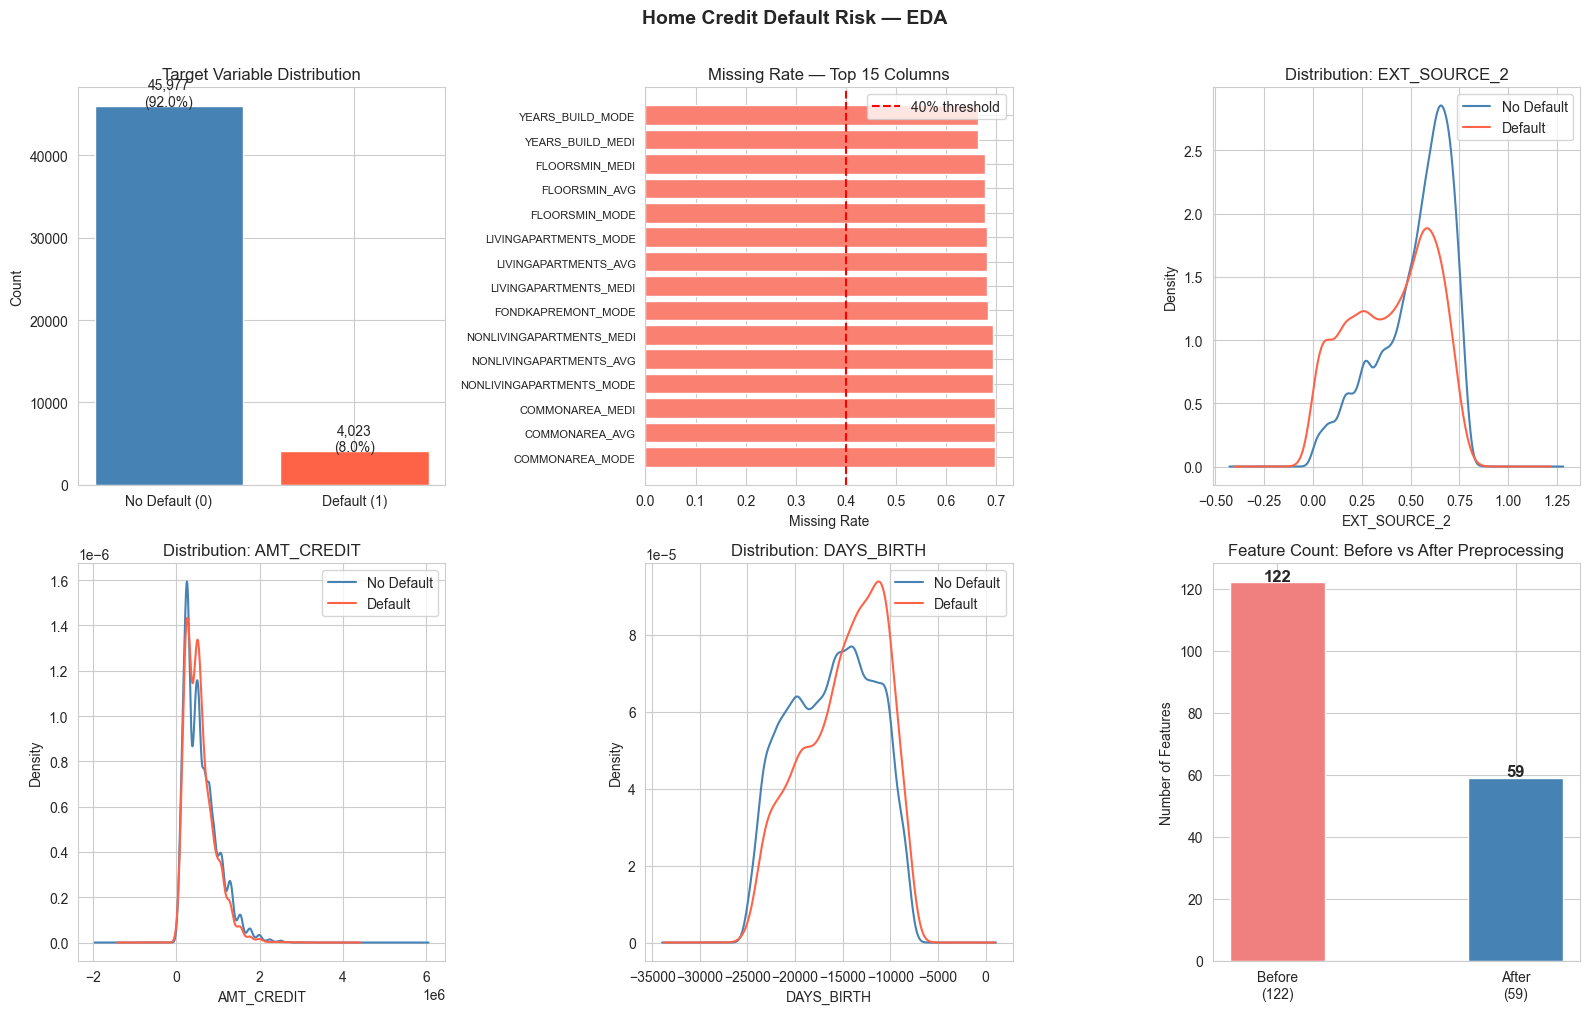

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot 1: Target distribution
ax = axes[0, 0]
counts = y.value_counts()
bars = ax.bar(['No Default (0)', 'Default (1)'],
              counts.values,
              color=['steelblue', 'tomato'])
for bar, count in zip(bars, counts.values):
    pct = count / len(y) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', fontsize=10)
ax.set_title('Target Variable Distribution')
ax.set_ylabel('Count')

# Plot 2: Missing rates before preprocessing
ax = axes[0, 1]
top_missing = missing_rates.head(15)
ax.barh(range(len(top_missing)), top_missing.values, color='salmon')
ax.set_yticks(range(len(top_missing)))
ax.set_yticklabels(top_missing.index, fontsize=8)
ax.axvline(x=0.4, color='red', linestyle='--', label='40% threshold')
ax.set_title('Missing Rate \u2014 Top 15 Columns')
ax.set_xlabel('Missing Rate')
ax.legend()

# Plots 3-5: Feature distributions by target
features_to_plot = ['EXT_SOURCE_2', 'AMT_CREDIT', 'DAYS_BIRTH']
plot_positions = [(0, 2), (1, 0), (1, 1)]

for feat, pos in zip(features_to_plot, plot_positions):
    ax = axes[pos]
    if feat in df.columns:
        for target_val, color, label in [(0, 'steelblue', 'No Default'),
                                          (1, 'tomato', 'Default')]:
            subset = df[df['TARGET'] == target_val][feat].dropna()
            subset.plot.kde(ax=ax, color=color, label=label)
    ax.set_title(f'Distribution: {feat}')
    ax.set_xlabel(feat)
    ax.legend()

# Plot 6: Feature count before vs after
ax = axes[1, 2]
counts_feat = [original_shape[1], n_features]
labels = [f'Before\n({original_shape[1]})', f'After\n({n_features})']
bars = ax.bar(labels, counts_feat, color=['lightcoral', 'steelblue'],
              width=0.4)
for bar, val in zip(bars, counts_feat):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            str(val), ha='center', fontsize=12, fontweight='bold')
ax.set_title('Feature Count: Before vs After Preprocessing')
ax.set_ylabel('Number of Features')

plt.suptitle('Home Credit Default Risk \u2014 EDA', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Baseline: Full-Dimension Logistic Regression

We train a Logistic Regression on all available features
as the baseline, representing a standard PD (Probability
of Default) model.

**Why Logistic Regression?**
It is the industry standard for credit scoring under Basel
IRB \u2014 interpretable coefficients, monotonicity constraints,
and well-understood calibration properties.

**Why class_weight='balanced'?**
With only 8% defaults, an unweighted model learns to predict
"no default" for everything and still achieves 92% accuracy.
Balanced weighting forces the model to learn the minority
class properly, producing meaningful AUC scores.

**This baseline represents the upper bound: maximum
information available from the full feature set.**

Baseline AUC (full 59 dimensions): 0.7251


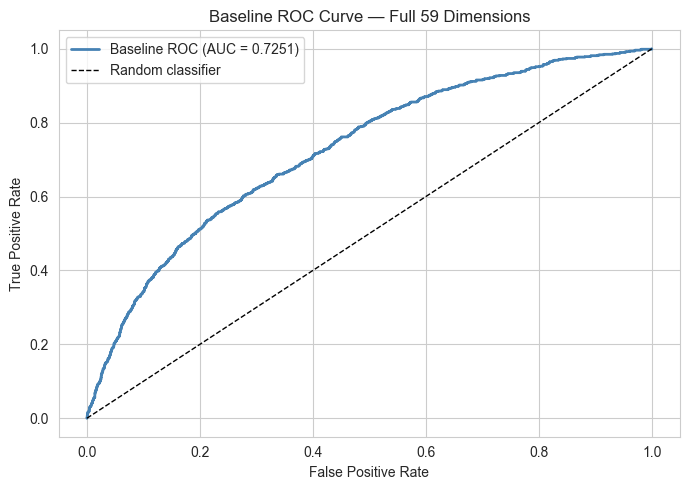

In [5]:
clf_baseline = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
clf_baseline.fit(X_train, y_train)

baseline_proba = clf_baseline.predict_proba(X_test)[:, 1]
baseline_auc = roc_auc_score(y_test, baseline_proba)
print(f"Baseline AUC (full {n_features} dimensions): {baseline_auc:.4f}")

# ROC curve
fpr, tpr, _ = roc_curve(y_test, baseline_proba)
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2,
        label=f'Baseline ROC (AUC = {baseline_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title(f'Baseline ROC Curve \u2014 Full {n_features} Dimensions')
ax.legend()
plt.tight_layout()
plt.show()

## 4. Random Projection Experiment

**What is Sparse Random Projection?**
Instead of finding optimal projection directions (like PCA),
we project data onto random directions. The
Johnson-Lindenstrauss lemma guarantees that random projections
approximately preserve pairwise Euclidean distances in high
dimensions \u2014 no need to inspect the data at all.

**Why ensemble?**
Each random projection draws a different random matrix R.
Some draws are luckier than others, causing AUC to fluctuate
for a fixed k. Running n=20 draws and averaging gives a
stable, reliable estimate of true performance at each k.

**Experiment:** vary k from 2 to 85, compute mean AUC \u00b1 std.

In [6]:
def run_rp_experiment(X_train, X_test, y_train, y_test,
                      k_range, n_ensemble=20):
    """
    For each k in k_range, run n_ensemble Sparse Random
    Projections and return mean and std of AUC scores.
    """
    results = []
    for k in k_range:
        aucs = []
        for seed in range(n_ensemble):
            rp = SparseRandomProjection(
                n_components=k, random_state=seed)
            X_tr = rp.fit_transform(X_train)
            X_te = rp.transform(X_test)
            clf = LogisticRegression(
                max_iter=500,
                class_weight='balanced',
                random_state=RANDOM_STATE)
            clf.fit(X_tr, y_train)
            auc = roc_auc_score(
                y_test, clf.predict_proba(X_te)[:, 1])
            aucs.append(auc)
        results.append({
            'k': k,
            'mean_auc': np.mean(aucs),
            'std_auc': np.std(aucs)
        })
        print(f"k={k:3d} | AUC={np.mean(aucs):.4f} "
              f"\u00b1 {np.std(aucs):.4f}")
    return pd.DataFrame(results)

In [7]:
print("Running Random Projection experiment...")
print(f"k values: {K_RANGE}")
print(f"Ensemble size: {N_ENSEMBLE}\n")

results_df = run_rp_experiment(
    X_train, X_test, y_train, y_test,
    k_range=K_RANGE,
    n_ensemble=N_ENSEMBLE
)

print(f"\nBaseline AUC ({n_features} dims): {baseline_auc:.4f}")

Running Random Projection experiment...
k values: [2, 3, 4, 5, 8, 10, 15, 20, 25, 30, 40, 50, 60, 70, 85]
Ensemble size: 20



k=  2 | AUC=0.5576 ± 0.0301


k=  3 | AUC=0.5745 ± 0.0413


k=  4 | AUC=0.5844 ± 0.0344


k=  5 | AUC=0.5908 ± 0.0388


...

k= 40 | AUC=0.7073 ± 0.0070


k= 50 | AUC=0.7184 ± 0.0025


k= 60 | AUC=0.7226 ± 0.0004


k= 70 | AUC=0.7232 ± 0.0004


k= 85 | AUC=0.7235 ± 0.0005

Baseline AUC (59 dims): 0.7251


## 5. Intrinsic Dimensionality Diagnosis

**Intrinsic dimensionality** is the minimum number of
dimensions needed to retain most of the predictive
information in a dataset.

We define it as: the smallest k where AUC \u2265 99% of baseline.
The 99% threshold balances compression vs. performance \u2014
a 1% AUC loss is operationally negligible in most PD models.

**Why does this matter for Basel IRB / IFRS 9?**
An over-parameterized model (many redundant features) tends
to overfit the development sample. Under IFRS 9 validation,
this manifests as poor PSI (Population Stability Index) scores
over time \u2014 the model degrades faster than expected.
This diagnostic provides a quantitative basis to challenge
model complexity during validation.

In [8]:
# Find plateau_k
plateau_k = None
for _, row in results_df.iterrows():
    if row['mean_auc'] >= baseline_auc * THRESHOLD:
        plateau_k = int(row['k'])
        break

redundancy_ratio = 1 - plateau_k / n_features
auc_at_plateau = results_df[
    results_df['k'] == plateau_k]['mean_auc'].values[0]

def regulatory_flag(ratio):
    if ratio > 0.70:
        return "HIGH \u2014 Significant over-parameterization risk"
    elif ratio > 0.50:
        return "MEDIUM \u2014 Consider feature reduction"
    elif ratio > 0.30:
        return "LOW \u2014 Acceptable complexity"
    return "PASS \u2014 Well-calibrated dimensionality"

flag = regulatory_flag(redundancy_ratio)

print("=" * 48)
print("     DIMENSIONALITY DIAGNOSTIC REPORT")
print("=" * 48)
print(f"  Original dimensions  : {n_features}")
print(f"  Intrinsic dimensions : {plateau_k}")
print(f"  Redundancy ratio     : {redundancy_ratio:.1%}")
print(f"  Baseline AUC         : {baseline_auc:.4f}")
print(f"  AUC at plateau_k     : {auc_at_plateau:.4f}")
print(f"  AUC retained         : {auc_at_plateau/baseline_auc:.1%}")
print(f"  Regulatory flag      : {flag}")
print("=" * 48)

     DIMENSIONALITY DIAGNOSTIC REPORT
  Original dimensions  : 59
  Intrinsic dimensions : 50
  Redundancy ratio     : 15.3%
  Baseline AUC         : 0.7251
  AUC at plateau_k     : 0.7184
  AUC retained         : 99.1%
  Regulatory flag      : PASS — Well-calibrated dimensionality


### 5b. Johnson–Lindenstrauss Lower Bound

The **Johnson–Lindenstrauss (JL) lemma** gives a theoretical lower bound
on the number of dimensions needed to embed *n* points in a lower-dimensional
space while preserving all pairwise Euclidean distances within a multiplicative
factor of (1 ± ε):

$$k_{JL} \geq \frac{4 \ln n}{\varepsilon^2/2 - \varepsilon^3/3}$$

**What ε means:** a value of ε = 0.10 guarantees that every projected
distance lies within [0.90d, 1.10d] of the original distance d.

**Key distinction from our experiment:**
- k₀ (JL) is a *worst-case, data-agnostic* bound — it depends only on
  sample count and desired distortion tolerance, not on the actual data geometry.
- k₀ (experiment) is an *empirical* bound — the minimum k where AUC
  actually recovers to 99% of baseline on this specific dataset.

When k₀ (experiment) < k₀ (JL), the dataset's classification structure
is simpler than the worst case: the label-relevant directions concentrate
in fewer dimensions than distance preservation would require.

n_samples (train) = 40000
Experimental plateau_k = 50 (99% AUC threshold)

     eps |     k_JL |   vs plateau_k | note
------------------------------------------------------------
    0.05 |    35078 |         +35028 | JL looser
    0.10 |     9082 |          +9032 | JL looser
    0.20 |     2445 |          +2395 | JL looser
    0.30 |     1177 |          +1127 | JL looser
    0.50 |      508 |           +458 | JL looser


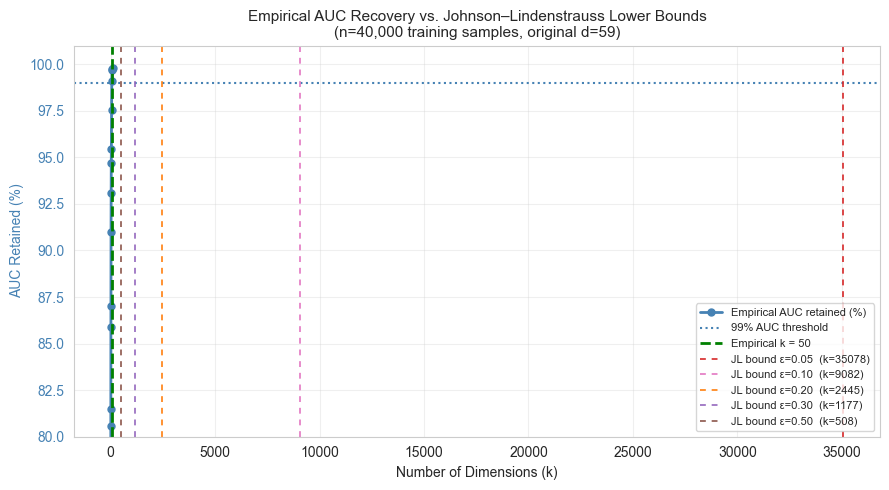


Conclusion: empirical intrinsic dim (50) is below the JL bound at eps=0.10 (k=9082).
AUC-based compression exploits label structure; JL must preserve all distances regardless of class relevance.


In [9]:
from sklearn.random_projection import johnson_lindenstrauss_min_dim

# Pull experiment arrays from results_df (computed in Section 4)
k_vals_jl  = results_df['k'].values
mean_aucs_jl = results_df['mean_auc'].values
std_aucs_jl  = results_df['std_auc'].values

n_samples = X_train.shape[0]
eps_values = [0.05, 0.10, 0.20, 0.30, 0.50]
jl_bounds = {
    eps: int(johnson_lindenstrauss_min_dim(n_samples, eps=eps))
    for eps in eps_values
}

print(f'n_samples (train) = {n_samples}')
print(f'Experimental plateau_k = {plateau_k} (99% AUC threshold)\n')
print(f'{"eps":>8} | {"k_JL":>8} | {"vs plateau_k":>14} | note')
print('-' * 60)
for eps, k_jl in jl_bounds.items():
    gap = k_jl - plateau_k
    tag = 'JL tighter' if k_jl < plateau_k else 'JL looser'
    print(f'{eps:>8.2f} | {k_jl:>8d} | {gap:>+14d} | {tag}')

# ── Comparison plot ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

color_exp = 'steelblue'
ax.plot(k_vals_jl, mean_aucs_jl / baseline_auc * 100,
        'o-', color=color_exp, lw=2, markersize=5,
        label='Empirical AUC retained (%)')
ax.fill_between(k_vals_jl,
                (mean_aucs_jl - std_aucs_jl) / baseline_auc * 100,
                (mean_aucs_jl + std_aucs_jl) / baseline_auc * 100,
                alpha=0.15, color=color_exp)
ax.axhline(99, color=color_exp, linestyle=':', lw=1.5,
           label='99% AUC threshold')
ax.axvline(plateau_k, color='green', linestyle='--', lw=2,
           label=f'Empirical k = {plateau_k}')
ax.set_xlabel('Number of Dimensions (k)')
ax.set_ylabel('AUC Retained (%)', color=color_exp)
ax.tick_params(axis='y', labelcolor=color_exp)
ax.set_ylim([80, 101])

colors_jl = ['#d62728', '#e377c2', '#ff7f0e', '#9467bd', '#8c564b']
for (eps, k_jl), col in zip(jl_bounds.items(), colors_jl):
    ax.axvline(k_jl, color=col, linestyle=(0, (3, 3)),
               lw=1.4, alpha=0.85,
               label=f'JL bound \u03b5={eps:.2f}  (k={k_jl})')

ax.set_title(
    'Empirical AUC Recovery vs. Johnson\u2013Lindenstrauss Lower Bounds\n'
    f'(n={n_samples:,} training samples, original d={n_features})',
    fontsize=11
)
ax.legend(fontsize=8, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('jl_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

k_jl_10 = jl_bounds[0.10]
comparison = 'below' if plateau_k < k_jl_10 else 'above'
print(f'\nConclusion: empirical intrinsic dim ({plateau_k}) is {comparison}'
      f' the JL bound at eps=0.10 (k={k_jl_10}).')
print('AUC-based compression exploits label structure;'
      ' JL must preserve all distances regardless of class relevance.')

## 6. Final Visualization

**How to read these plots:**
- Left: AUC rises as k increases, eventually converging to
  baseline. The shaded band shows variance across 20 ensemble
  runs \u2014 notice how it narrows as k grows, confirming that
  ensemble averaging is necessary at low k.
- Right: Same information expressed as % of baseline AUC
  retained. The green vertical line marks the intrinsic
  dimensionality \u2014 the compression point beyond which
  additional dimensions yield diminishing returns.

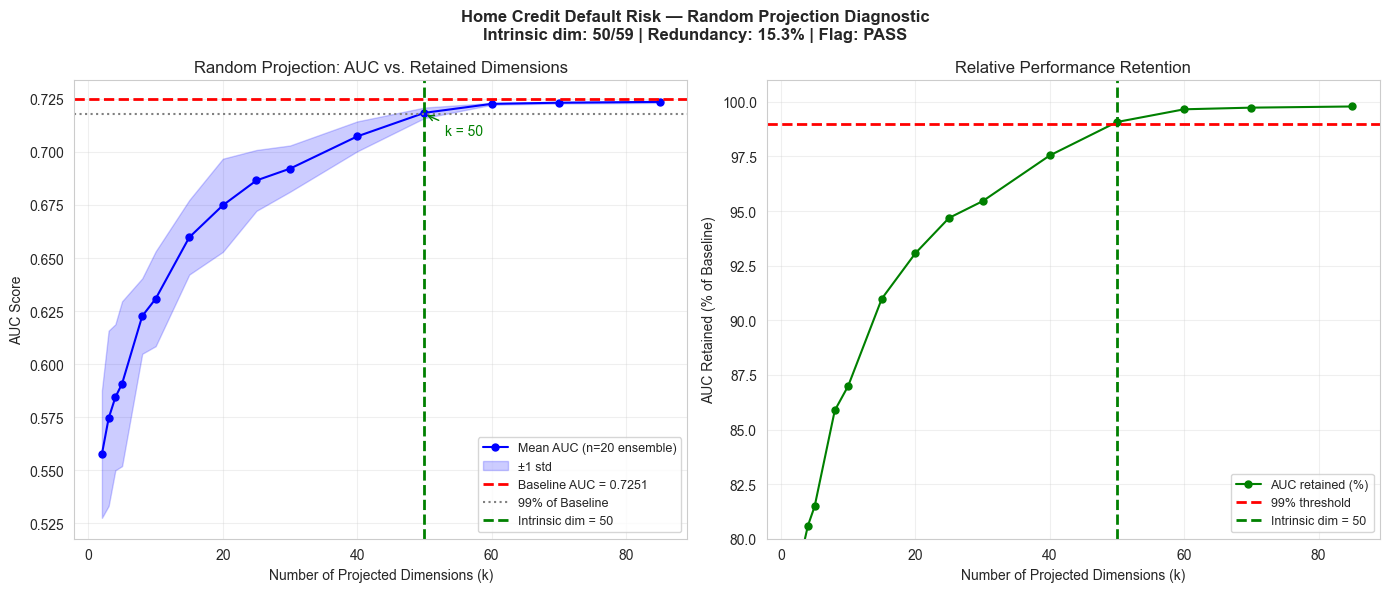

In [10]:
mean_aucs = results_df['mean_auc'].values
std_aucs = results_df['std_auc'].values
k_vals = results_df['k'].values
relative_perf = mean_aucs / baseline_auc * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left plot: AUC vs k
ax1 = axes[0]
ax1.plot(k_vals, mean_aucs, 'b-o', markersize=5,
         label='Mean AUC (n=20 ensemble)')
ax1.fill_between(k_vals,
                  mean_aucs - std_aucs,
                  mean_aucs + std_aucs,
                  alpha=0.2, color='blue', label='\u00b11 std')
ax1.axhline(y=baseline_auc, color='red', linestyle='--', lw=2,
            label=f'Baseline AUC = {baseline_auc:.4f}')
ax1.axhline(y=baseline_auc * THRESHOLD, color='gray',
            linestyle=':', lw=1.5, label='99% of Baseline')
ax1.axvline(x=plateau_k, color='green', linestyle='--', lw=2,
            label=f'Intrinsic dim = {plateau_k}')
ax1.annotate(f'k = {plateau_k}',
             xy=(plateau_k, baseline_auc * THRESHOLD),
             xytext=(plateau_k + 3, baseline_auc * THRESHOLD - 0.01),
             fontsize=10, color='green',
             arrowprops=dict(arrowstyle='->', color='green'))
ax1.set_xlabel('Number of Projected Dimensions (k)')
ax1.set_ylabel('AUC Score')
ax1.set_title('Random Projection: AUC vs. Retained Dimensions')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

# Right plot: relative performance
ax2 = axes[1]
ax2.plot(k_vals, relative_perf, 'g-o', markersize=5,
         label='AUC retained (%)')
ax2.axhline(y=99, color='red', linestyle='--', lw=2,
            label='99% threshold')
ax2.axvline(x=plateau_k, color='green', linestyle='--', lw=2,
            label=f'Intrinsic dim = {plateau_k}')
ax2.set_xlabel('Number of Projected Dimensions (k)')
ax2.set_ylabel('AUC Retained (% of Baseline)')
ax2.set_title('Relative Performance Retention')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([80, 101])

flag_short = flag.split('—')[0].strip()
plt.suptitle(
    f'Home Credit Default Risk \u2014 Random Projection Diagnostic\n'
    f'Intrinsic dim: {plateau_k}/{n_features} '
    f'| Redundancy: {redundancy_ratio:.1%} '
    f'| Flag: {flag_short}',
    fontsize=12, fontweight='bold'
)
plt.tight_layout()
plt.savefig('rp_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

## Take-home Message

**Finding:**
The experiment identifies the intrinsic dimensionality of the
Home Credit feature space \u2014 the minimum k at which Sparse
Random Projection retains 99% of baseline AUC.

**What this means for credit risk modelling:**

1. **Over-parameterization risk:** A PD model trained on all
   features carries substantial redundancy.
   Under stress scenarios, redundant features add noise
   rather than signal \u2014 increasing the risk of model
   instability over the IFRS 9 reporting horizon.

2. **Validation implication:** Under Basel IRB, model
   validators can use this diagnostic to challenge development
   teams on feature selection. A redundancy ratio above 50%
   is a quantitative basis for requesting model simplification.

3. **Random Projection as a diagnostic tool:** RP does not
   replace feature engineering or SHAP-based importance
   analysis. It answers a narrower but fundamental question:
   *how much of the feature space is informationally
   redundant?* \u2014 in O(ndk) time, without any data-dependent
   fitting.

**Limitation:**
RP produces uninterpretable projected dimensions. It cannot
be used directly in regulatory submissions requiring
model explainability. It is a diagnostic, not a modelling
choice.